In [9]:
import xarray as xr
import climtas.nci
import matplotlib.pyplot as plt
from statsmodels.distributions.empirical_distribution import ECDF
#climtas.nci.GadiClient()

In [5]:
def test_gcm(lon, lat, model, month):

    da_gcm = xr.open_mfdataset("/g/data/eg3/ab4502/ExtremeWind/global/"+model+"/"+model+"_historical_r1i1p1_*.nc").laplacian
    da_gcm = da_gcm.sel({"time":(da_gcm["time.month"] == month) & (da_gcm["time.year"] < 2006) & (da_gcm["time.year"] > 1978)})  
    vals_gcm = da_gcm.interp({"lat":lat,"lon":lon},method="nearest").values
    
    da_qm_hist = xr.open_mfdataset("/g/data/eg3/ab4502/ExtremeWind/global/regrid_1.5/"+model+"_r1i1p1_historical_laplacian_qm_1979_2005.nc",chunks={"time":200}).laplacian
    da_qm_hist = da_qm_hist.sel({"time":(da_qm_hist["time.month"] == month)})    
    vals_qm_hist = da_qm_hist.sel({"lat":lat,"lon":lon}).values
    
    da_qm_rcp = xr.open_mfdataset("/g/data/eg3/ab4502/ExtremeWind/global/regrid_1.5/"+model+"_r1i1p1_rcp85_laplacian_qm_2081_2100.nc",chunks={"time":200}).laplacian
    da_qm_rcp = da_qm_rcp.sel({"time":(da_qm_rcp["time.month"] == month)})    
    vals_qm_rcp = da_qm_rcp.sel({"lat":lat,"lon":lon}).values
    
    return vals_gcm,  vals_qm_hist, vals_qm_rcp

def test_era5(lon, lat, month):
    
    da_era5 = xr.open_mfdataset("/g/data/eg3/ab4502/ExtremeWind/global/era5/*.nc").laplacian
    da_era5 = da_era5.sel({"time":(da_era5["time.month"] == month) & (da_era5["time.year"] < 2006)})
    vals_era5 = da_era5.sel({"lat":lat,"lon":lon}).values
    
    return vals_era5
    

In [7]:
era5 = test_era5(130, -44, 12)
access, access_qm1, access_qm2 = test_gcm(130, -44, "ACCESS1-0", 12)
mri_cgcm, mri_cgcm_qm1, mri_cgcm_qm2 = test_gcm(130, -44, "MRI-CGCM3", 12)

Text(0.5, 0.98, '(130.0, -44.0)')

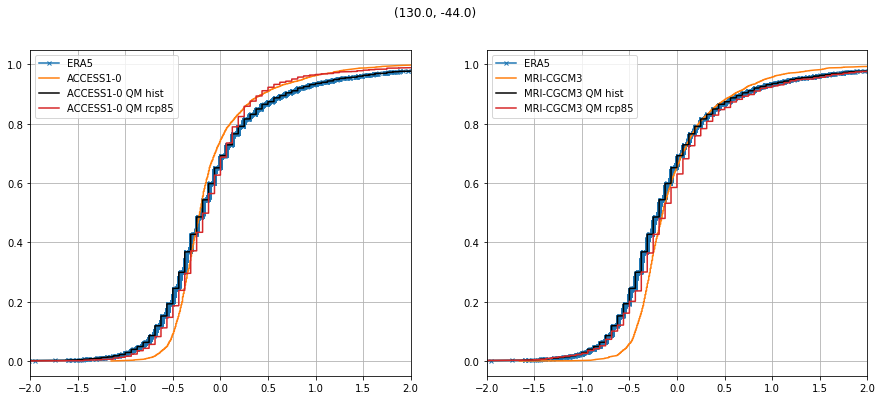

In [19]:
plt.figure(figsize=[15,6])

plt.subplot(1,2,1)

plt.plot(ECDF(era5).x, ECDF(era5).y, color="tab:blue", marker="x", ms=4, label="ERA5")
plt.plot(ECDF(access).x, ECDF(access).y, color="tab:orange", label="ACCESS1-0")
plt.plot(ECDF(access_qm1).x, ECDF(access_qm1).y, color="k", label="ACCESS1-0 QM hist")
plt.plot(ECDF(access_qm2).x, ECDF(access_qm2).y, color="tab:red", label="ACCESS1-0 QM rcp85")
plt.xlim([-2,2])
plt.legend()
plt.gca().grid()

plt.subplot(1,2,2)

plt.plot(ECDF(era5).x, ECDF(era5).y, color="tab:blue", marker="x", ms=4, label="ERA5")
plt.plot(ECDF(mri_cgcm).x, ECDF(mri_cgcm).y, color="tab:orange", label="MRI-CGCM3")
plt.plot(ECDF(mri_cgcm_qm1).x, ECDF(mri_cgcm_qm1).y, color="k", label="MRI-CGCM3 QM hist")
plt.plot(ECDF(mri_cgcm_qm2).x, ECDF(mri_cgcm_qm2).y, color="tab:red", label="MRI-CGCM3 QM rcp85")
plt.xlim([-2,2])
plt.legend()
plt.gca().grid()

plt.suptitle("(130.0, -44.0)")

In [20]:
era5 = test_era5(146, -36.5, 12)
access, access_qm1, access_qm2 = test_gcm(146, -36.5, "ACCESS1-0", 12)
mri_cgcm, mri_cgcm_qm1, mri_cgcm_qm2 = test_gcm(146, -36.5, "MRI-CGCM3", 12)

Text(0.5, 0.98, '(146, -36.5)')

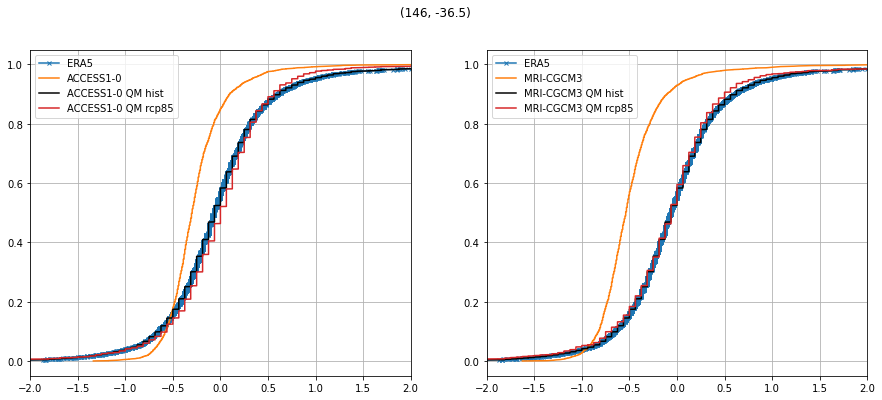

In [21]:
plt.figure(figsize=[15,6])

plt.subplot(1,2,1)

plt.plot(ECDF(era5).x, ECDF(era5).y, color="tab:blue", marker="x", ms=4, label="ERA5")
plt.plot(ECDF(access).x, ECDF(access).y, color="tab:orange", label="ACCESS1-0")
plt.plot(ECDF(access_qm1).x, ECDF(access_qm1).y, color="k", label="ACCESS1-0 QM hist")
plt.plot(ECDF(access_qm2).x, ECDF(access_qm2).y, color="tab:red", label="ACCESS1-0 QM rcp85")
plt.xlim([-2,2])
plt.legend()
plt.gca().grid()

plt.subplot(1,2,2)

plt.plot(ECDF(era5).x, ECDF(era5).y, color="tab:blue", marker="x", ms=4, label="ERA5")
plt.plot(ECDF(mri_cgcm).x, ECDF(mri_cgcm).y, color="tab:orange", label="MRI-CGCM3")
plt.plot(ECDF(mri_cgcm_qm1).x, ECDF(mri_cgcm_qm1).y, color="k", label="MRI-CGCM3 QM hist")
plt.plot(ECDF(mri_cgcm_qm2).x, ECDF(mri_cgcm_qm2).y, color="tab:red", label="MRI-CGCM3 QM rcp85")
plt.xlim([-2,2])
plt.legend()
plt.gca().grid()

plt.suptitle("(146, -36.5)")